In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
np.random.seed(42)

# Clase 0
X0 = np.random.randn(50, 2) + np.array([-2, -2])

# Clase 1
X1 = np.random.randn(50, 2) + np.array([2, 2])

# Unimos datos
X = np.vstack((X0, X1))

# Labels
y = np.hstack((np.zeros(50), np.ones(50)))

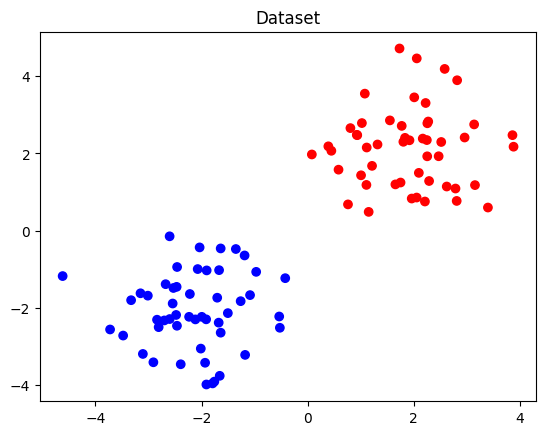

In [19]:
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
plt.title("Dataset")
plt.show()

In [20]:
class Perceptron:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None

In [21]:
    def activation(self, x):
        return np.where(x >= 0, 1, 0)

In [22]:
    def predict(self, X):
        linear = np.dot(X, self.weights) + self.bias
        return self.activation(linear)

In [23]:
class Perceptron:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def activation(self, x):
        return np.where(x >= 0, 1, 0)

    def predict(self, X):
        linear = np.dot(X, self.weights) + self.bias
        return self.activation(linear)

    def train(self, X, y):   # ✅ ADENTRO de la clase
        n_samples, n_features = X.shape

        self.weights = np.random.randn(n_features)
        self.bias = 0

        errors = []

        for epoch in range(self.epochs):
            error_count = 0

            for i in range(n_samples):
                linear = np.dot(X[i], self.weights) + self.bias
                y_pred = self.activation(linear)

                error = y[i] - y_pred

                if error != 0:
                    self.weights += self.lr * error * X[i]
                    self.bias += self.lr * error
                    error_count += 1

            errors.append(error_count)

        return errors

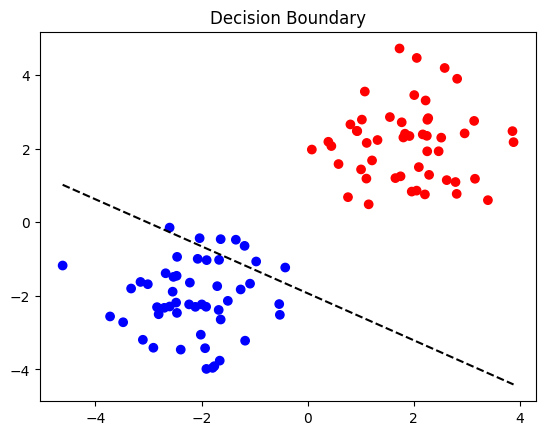

In [24]:
model = Perceptron(lr=0.1, epochs=50)

# Inicializamos pesos manualmente (porque aún no entrenamos)
model.weights = np.random.randn(2)
model.bias = np.random.randn()

plot_decision_boundary(X, y, model)

In [25]:
model = Perceptron(lr=0.1, epochs=50)
errors = model.train(X, y)

In [26]:
def plot_decision_boundary(X, y, model):
    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')

    x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
    y_vals = -(model.weights[0]*x_vals + model.bias) / model.weights[1]

    plt.plot(x_vals, y_vals, 'k--')
    plt.title("Decision Boundary")
    plt.show()

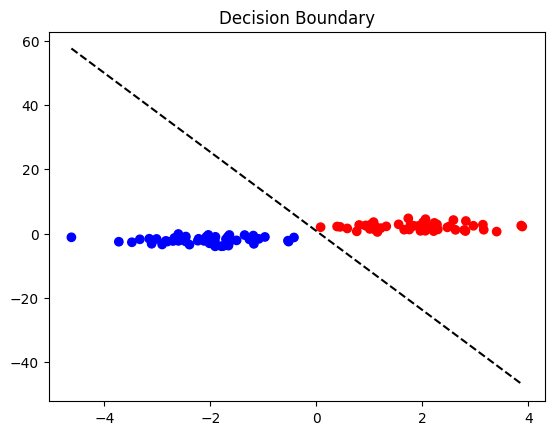

In [27]:
plot_decision_boundary(X, y, model)

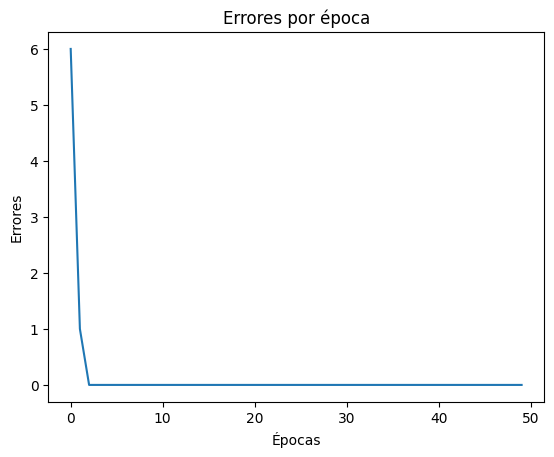

In [28]:
plt.plot(errors)
plt.title("Errores por época")
plt.xlabel("Épocas")
plt.ylabel("Errores")
plt.show()

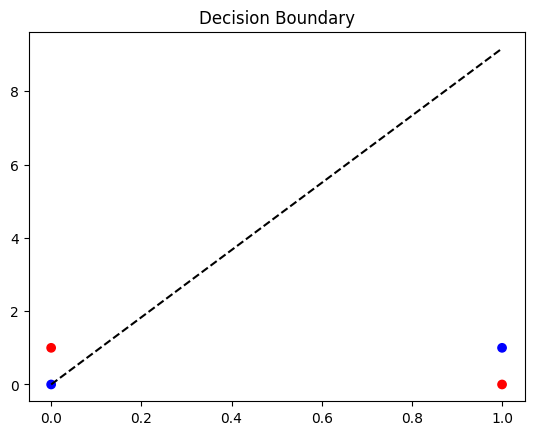

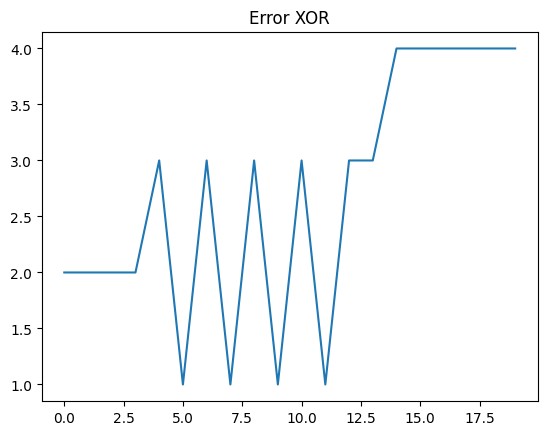

In [29]:
X_xor = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_xor = np.array([0,1,1,0])

model_xor = Perceptron(lr=0.1, epochs=20)
errors_xor = model_xor.train(X_xor, y_xor)

plot_decision_boundary(X_xor, y_xor, model_xor)

plt.plot(errors_xor)
plt.title("Error XOR")
plt.show()

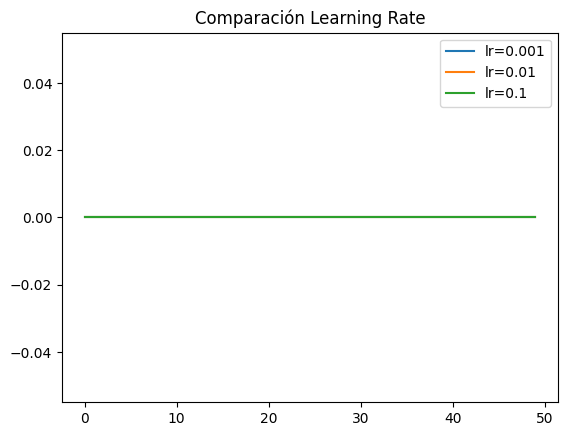

In [30]:
for lr in [0.001, 0.01, 0.1]:
    model = Perceptron(lr=lr, epochs=50)
    errors = model.train(X, y)

    plt.plot(errors, label=f"lr={lr}")

plt.legend()
plt.title("Comparación Learning Rate")
plt.show()

**1. ¿POR QUÉ EL PATRÓN NO PUEDE RESOLVER XOR?**

El perceptrón solo puede aprender fronteras de decisión lineales, es decir, rectas en un espacio 2D.

distribuidos de manera que los puntos de la misma clase se encuentran en posiciones diagonales opuestas. Esto implica que no existe una única recta que pueda separar correctamente ambas clases.

Al entrenar el perceptrón con este dataset, el modelo intenta ajustar sus pesos continuamente, pero no logra encontrar una solución que minimice el error a cero. Por eso, el error no converge y presenta oscilaciones durante el entrenamiento.

Esto demuestra que el perceptrón no puede resolver problemas que requieren fronteras de decisión no lineales.


**2. ¿QUÉ PASA SI CAMBIAN EL LEARNING RATE?**

El learning rate determina qué tan grandes son los ajustes que el modelo realiza sobre los pesos en cada actualización.

Al probar distintos valores:

* Con un learning rate bajo (por ejemplo, 0.001), el modelo aprende más lentamente, ya que los cambios en los pesos son pequeños.
* Con un valor intermedio (0.01), el aprendizaje es más equilibrado y suele converger de manera estable.
* Con un valor alto (0.1), el modelo puede converger muy rápidamente en problemas simples, como en este caso, donde los datos son fácilmente separables.

En este experimento, se observa que todos los valores logran converger, pero a distintas velocidades, debido a la simplicidad del dataset.


**3. ¿CUÁNTAS ÉPOCAS NECESITÓ PARA CONVENGER? ¿DE QUÉ DEPENDE?**

En este caso, el perceptrón convergió en muy pocas épocas, incluso desde la primera, lo cual se observa en el gráfico de error por época, donde el error se vuelve cero rápidamente.

La cantidad de épocas necesarias para converger depende de varios factores:

* La separabilidad de los datos (si son linealmente separables o no).
* El learning rate.
* La inicialización de los pesos.
* La distribución de los datos.

Cuando los datos están claramente separados, como en este caso, el modelo puede encontrar una solución muy rápidamente.